# Maskininlärningsprojekt: Klassificering av brösttumörer

I detta projekt används Breast Cancer Wisconsin-datasetet från Scikit-learn.

Målet är att träna en enkel maskininlärningsmodell som kan förutsäga om en brösttumör är godartad eller elakartad utifrån numeriska mätvärden från cellprover.

Detta är ett klassificeringsproblem eftersom modellen ska välja mellan två kategorier:

- elakartad tumör
- godartad tumör

Projektet genomförs med en enkel logistisk regressionsmodell.

In [ ]:
# ============================================================
# Steg 1: Importera bibliotek
# ============================================================

# pandas används för att hantera data i tabellform,
# ungefär som ett Excel-ark fast i Python.
import pandas as pd

# matplotlib används för att skapa diagram och visualiseringar.
import matplotlib.pyplot as plt

# load_breast_cancer används för att ladda in datasetet
# Breast Cancer Wisconsin direkt från Scikit-learn.
from sklearn.datasets import load_breast_cancer

# train_test_split används för att dela upp datasetet i
# träningsdata och testdata.
from sklearn.model_selection import train_test_split

# StandardScaler används för att standardisera numeriska värden.
# Det gör att olika features hamnar på en mer jämförbar skala.
from sklearn.preprocessing import StandardScaler

# LogisticRegression är den maskininlärningsmodell vi ska använda.
# Den passar bra för klassificeringsproblem med två klasser.
from sklearn.linear_model import LogisticRegression

# Dessa funktioner används för att utvärdera hur bra modellen presterar.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Steg 2: Ladda in och undersöka datasetet

I detta steg laddas Breast Cancer Wisconsin-datasetet in från Scikit-learn.

Datasetet innehåller numeriska mätvärden från cellprover. Målet är att använda dessa mätvärden för att förutsäga om en tumör är elakartad eller godartad.

In [ ]:
# ============================================================
# Steg 2: Ladda in och undersöka datasetet
# ============================================================

# Laddar in Breast Cancer Wisconsin-datasetet från Scikit-learn.
# Datasetet följer med biblioteket, så vi behöver inte ladda ner någon fil manuellt.
cancer_data = load_breast_cancer()

# Skapar en tabell med alla features, alltså de mätvärden som modellen ska använda.
# Varje rad motsvarar ett prov och varje kolumn är ett mätvärde.
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# Skapar en separat serie med target-värdet.
# Target är det värde som modellen senare ska försöka förutsäga.
y = pd.Series(cancer_data.target, name="target")

# Skapar en komplett DataFrame där features och target finns i samma tabell.
df = X.copy()
df["target"] = y

# Gör target-värdet mer lättläst genom att lägga till en textkolumn.
# I detta dataset betyder:
# 0 = elakartad tumör
# 1 = godartad tumör
df["diagnosis"] = df["target"].map({
    0: "elakartad",
    1: "godartad"
})

# Skriver ut hur många rader och kolumner datasetet har.
print("Antal rader och kolumner i datasetet:")
print(df.shape)

# Skriver ut vilka klasser som finns i datasetet.
print("\nKlasser i datasetet:")
print(cancer_data.target_names)

# Visar de fem första raderna i tabellen.
df.head()

Antal rader och kolumner i datasetet:
(569, 32)

Klasser i datasetet:
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,elakartad
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,elakartad
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,elakartad
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,elakartad
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,elakartad


## Steg 3: Kontrollera saknade värden och målvariabeln

Innan modellen tränas behöver datasetet kontrolleras.

I detta steg undersöks:

- om det finns saknade värden
- vilka datatyper som finns
- hur många exempel som finns av varje diagnos

Målvariabeln är `target`, alltså det värde som modellen senare ska lära sig att förutsäga.

In [ ]:
# ============================================================
# Steg 3: Kontrollera saknade värden och målvariabeln
# ============================================================

# Kontrollerar om det finns saknade värden i datasetet.
# Saknade värden betyder att någon cell i tabellen saknar information.
missing_values = df.isnull().sum()

# Räknar totalt antal saknade värden i hela datasetet.
total_missing = missing_values.sum()

print("Totalt antal saknade värden i datasetet:")
print(total_missing)

# Om det finns saknade värden skriver vi ut vilka kolumner det gäller.
# Om det inte finns några saknade värden skriver vi ut ett tydligt meddelande.
if total_missing > 0:
    print("\nSaknade värden per kolumn:")
    print(missing_values[missing_values > 0])
else:
    print("\nDet finns inga saknade värden i datasetet.")

# Kontrollerar vilka datatyper som finns i datasetet.
# Detta hjälper oss att se om värdena är numeriska eller textbaserade.
print("\nDatatyper i datasetet:")
print(df.dtypes.value_counts())

# Visar hur många exempel det finns av varje diagnos.
# Detta är viktigt eftersom modellen behöver exempel från båda klasserna.
print("\nAntal prover per diagnos:")
print(df["diagnosis"].value_counts())

# Visar samma information i procent.
print("\nAndel prover per diagnos i procent:")
print((df["diagnosis"].value_counts(normalize=True) * 100).round(2))

Totalt antal saknade värden i datasetet:
0

Det finns inga saknade värden i datasetet.

Datatyper i datasetet:
float64    30
int64       1
object      1
Name: count, dtype: int64

Antal prover per diagnos:
diagnosis
godartad     357
elakartad    212
Name: count, dtype: int64

Andel prover per diagnos i procent:
diagnosis
godartad     62.74
elakartad    37.26
Name: proportion, dtype: float64


## Steg 4: Visualisering av datasetet

För att få en bättre förståelse för datasetet skapas en visualisering.

Diagrammet visar hur många prover som är godartade respektive elakartade. Detta är relevant eftersom en modell kan påverkas om det finns mycket fler exempel av en klass än av en annan.

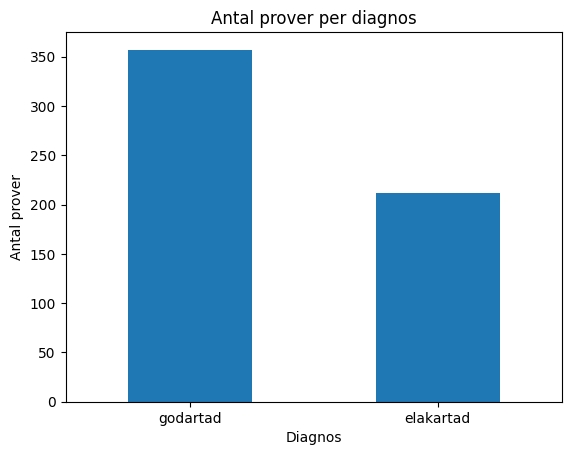

In [ ]:
# ============================================================
# Steg 4: Visualisering av datasetet
# ============================================================

# Räknar hur många prover det finns av varje diagnos.
# Detta ger oss underlag till stapeldiagrammet.
diagnosis_counts = df["diagnosis"].value_counts()

# Skapar ett stapeldiagram.
# Diagrammet visar fördelningen mellan godartade och elakartade tumörer.
diagnosis_counts.plot(kind="bar")

# Lägger till en tydlig rubrik.
plt.title("Antal prover per diagnos")

# Lägger till etiketter på x- och y-axeln.
plt.xlabel("Diagnos")
plt.ylabel("Antal prover")

# Gör så att texten på x-axeln visas rakt och inte snett.
plt.xticks(rotation=0)

# Visar diagrammet.
plt.show()

## Steg 5: Välja features och målvariabel

I detta steg väljs vilka delar av datasetet som modellen ska använda.

Features är de värden som modellen får som input. I detta projekt används de 30 numeriska mätvärdena från cellproverna.

Målvariabeln är det modellen ska lära sig att förutsäga. I detta projekt är målvariabeln `target`, där:

- 0 betyder elakartad tumör
- 1 betyder godartad tumör

Kolumnen `diagnosis` används endast för att göra tabellen lättare att läsa. Den ska inte användas som input till modellen.

In [ ]:
# ============================================================
# Steg 5: Välja features och målvariabel
# ============================================================

# X_model innehåller de features som modellen ska använda.
# Här använder vi de 30 ursprungliga numeriska mätvärdena.
# Vi använder INTE kolumnerna "target" eller "diagnosis" som input,
# eftersom target är det modellen ska förutsäga och diagnosis bara är en textversion.
X_model = X.copy()

# y_model innehåller målvariabeln, alltså det modellen ska lära sig att förutsäga.
# I detta dataset betyder:
# 0 = elakartad tumör
# 1 = godartad tumör
y_model = y.copy()

# Skriver ut hur många features modellen kommer att använda.
print("Antal features som används i modellen:")
print(X_model.shape[1])

# Skriver ut hur många exempel/rader som finns.
print("\nAntal exempel i datasetet:")
print(X_model.shape[0])

# Visar namnen på de första features som används.
print("\nExempel på features:")
print(X_model.columns[:10].tolist())

Antal features som används i modellen:
30

Antal exempel i datasetet:
569

Exempel på features:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']


## Steg 6: Dela upp datasetet i träningsdata och testdata

Datasetet delas upp i två delar:

- träningsdata
- testdata

Träningsdatan används för att modellen ska lära sig mönster i datan.

Testdatan används efter träningen för att kontrollera hur bra modellen fungerar på data som den inte har sett tidigare.

I detta projekt används 80 % av datan till träning och 20 % till test.

In [ ]:
# ============================================================
# Steg 6: Dela upp datasetet i träningsdata och testdata
# ============================================================

# Datasetet delas upp i träningsdata och testdata.
#
# X_train = features som modellen tränas på
# X_test  = features som modellen testas på
# y_train = rätt svar för träningsdatan
# y_test  = rätt svar för testdatan
#
# test_size=0.2 betyder att 20 % av datan används som testdata.
# random_state=42 gör att uppdelningen blir samma varje gång koden körs.
# stratify=y_model gör att fördelningen mellan elakartade och godartade
# tumörer blir ungefär lika i både träningsdata och testdata.

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

# Skriver ut storleken på tränings- och testdatan.
print("Storlek på träningsdata:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nStorlek på testdata:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# Kontrollerar fördelningen av klasser i träningsdatan.
print("\nFördelning i träningsdata:")
print(y_train.value_counts(normalize=True).round(3))

# Kontrollerar fördelningen av klasser i testdatan.
print("\nFördelning i testdata:")
print(y_test.value_counts(normalize=True).round(3))

Storlek på träningsdata:
X_train: (455, 30)
y_train: (455,)

Storlek på testdata:
X_test: (114, 30)
y_test: (114,)

Fördelning i träningsdata:
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Fördelning i testdata:
target
1    0.632
0    0.368
Name: proportion, dtype: float64


## Steg 7: Standardisera numeriska värden

De numeriska värdena i datasetet kan ligga på olika skalor. En feature kan till exempel ha små värden, medan en annan feature har mycket större värden.

För att modellen ska kunna arbeta mer rättvist med alla features standardiseras datan med `StandardScaler`.

Standardisering innebär att värdena görs om så att varje feature får ungefär:

- medelvärde 0
- standardavvikelse 1

Viktigt: `StandardScaler` anpassas bara på träningsdatan. Testdatan ska inte användas för att lära sig skalningen, eftersom testdatan ska föreställa ny data som modellen inte har sett tidigare.

In [ ]:
# ============================================================
# Steg 7: Standardisera numeriska värden
# ============================================================

# Skapar ett StandardScaler-objekt.
# Detta objekt används för att räkna ut hur varje feature ska standardiseras.
scaler = StandardScaler()

# Anpassar scaler på träningsdatan och standardiserar träningsdatan.
#
# fit_transform gör två saker:
# 1. fit: räknar ut medelvärde och standardavvikelse från träningsdatan
# 2. transform: använder dessa värden för att standardisera träningsdatan
X_train_scaled = scaler.fit_transform(X_train)

# Standardiserar testdatan med samma scaler.
#
# Här används bara transform, inte fit_transform.
# Det är viktigt eftersom testdatan inte ska påverka hur skalningen beräknas.
X_test_scaled = scaler.transform(X_test)

# Skriver ut formen på den standardiserade datan.
# Formen ska vara samma som tidigare: samma antal rader och features.
print("Form på standardiserad träningsdata:")
print(X_train_scaled.shape)

print("\nForm på standardiserad testdata:")
print(X_test_scaled.shape)

# Visar de första fem värdena från första raden i träningsdatan,
# så att vi kan se att värdena nu har standardiserats.
print("\nExempel på standardiserade värden från första träningsraden:")
print(X_train_scaled[0][:5])

Form på standardiserad träningsdata:
(455, 30)

Form på standardiserad testdata:
(114, 30)

Exempel på standardiserade värden från första träningsraden:
[-1.07200079 -0.6584246  -1.0880801  -0.93927364 -0.13593988]


## Steg 8: Skapa och träna modellen

I detta steg skapas och tränas en logistisk regressionsmodell.

Logistisk regression är en maskininlärningsmodell som passar bra för klassificeringsproblem där modellen ska välja mellan olika klasser.

I detta projekt ska modellen förutsäga om en tumör är:

- elakartad
- godartad

Modellen tränas på träningsdatan. Det betyder att modellen får se både mätvärdena och de rätta svaren, så att den kan lära sig mönster i datan.

In [ ]:
from sklearn.linear_model import LogisticRegression

# ============================================================
# Steg 8: Skapa och träna modellen
# ============================================================

# Skapar en logistisk regressionsmodell.
#
# LogisticRegression används eftersom problemet är ett klassificeringsproblem.
# Modellen ska alltså välja mellan två klasser:
# 0 = elakartad tumör
# 1 = godartad tumör
#
# max_iter=1000 betyder att modellen får tillräckligt många försök
# att hitta en fungerande lösning.
# random_state=42 används för att resultatet ska bli mer reproducerbart.
model = LogisticRegression(max_iter=1000, random_state=42)

# Tränar modellen på den standardiserade träningsdatan.
#
# X_train_scaled innehåller mätvärdena som modellen ska lära sig från.
# y_train innehåller de rätta svaren för träningsdatan.
model.fit(X_train_scaled, y_train)

# Skriver ut ett enkelt meddelande när modellen har tränats klart.
print("Modellen är tränad och klar.")

# Visar vilka klasser modellen kan förutsäga.
print("\nKlasser som modellen kan förutsäga:")
print(model.classes_)

Modellen är tränad och klar.

Klasser som modellen kan förutsäga:
[0 1]


## Steg 9: Testa modellen på testdatan

När modellen har tränats ska den testas på testdatan.

Testdatan består av exempel som modellen inte använde under träningen. Det gör att vi kan få en bättre uppfattning om hur modellen fungerar på ny data.

I detta steg får modellen göra förutsägelser på `X_test_scaled`.

In [ ]:
# ============================================================
# Steg 9: Testa modellen på testdatan
# ============================================================

# Modellen gör förutsägelser på testdatan.
#
# X_test_scaled innehåller de standardiserade mätvärdena för testdatan.
# y_pred kommer att innehålla modellens förutsägelser.
y_pred = model.predict(X_test_scaled)

# Skriver ut de första 10 förutsägelserna.
print("De första 10 förutsägelserna:")
print(y_pred[:10])

# Skriver ut de första 10 rätta svaren från testdatan.
print("\nDe första 10 rätta svaren:")
print(y_test.values[:10])

De första 10 förutsägelserna:
[0 1 0 1 0 1 1 0 0 0]

De första 10 rätta svaren:
[0 1 0 1 0 1 1 0 0 0]


## Steg 10: Utvärdera modellen

I detta steg utvärderas modellen med flera mått:

- Accuracy visar hur stor andel av alla förutsägelser som blev rätt.
- Precision visar hur ofta modellen hade rätt när den förutsade en viss klass.
- Recall visar hur stor andel av de faktiska fallen i en viss klass som modellen hittade.
- F1-score är ett sammanvägt mått mellan precision och recall.

Eftersom detta handlar om tumörer är det särskilt viktigt att titta på hur modellen hanterar elakartade tumörer. Därför beräknas precision, recall och F1-score med elakartad tumör som positiv klass.

In [ ]:
# ============================================================
# Steg 10: Utvärdera modellen
# ============================================================

# Importerar utvärderingsmått.
# Detta gör cellen tydligare och minskar risken för fel om tidigare importer inte finns kvar.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Beräknar accuracy.
# Accuracy visar andelen rätta förutsägelser totalt.
accuracy = accuracy_score(y_test, y_pred)

# I detta dataset betyder:
# 0 = elakartad tumör
# 1 = godartad tumör
#
# Här använder vi pos_label=0 eftersom vi vill fokusera på
# hur modellen presterar för elakartade tumörer.
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)

# Skriver ut resultaten avrundade till tre decimaler.
print("Modellens resultat:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

# Skapar en confusion matrix.
# Den visar hur många fall som blev rätt och fel för varje klass.
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion matrix:")
print(cm)

# Skapar en mer lättläst version av confusion matrix.
cm_df = pd.DataFrame(
    cm,
    index=["Faktisk elakartad", "Faktisk godartad"],
    columns=["Förutsagd elakartad", "Förutsagd godartad"]
)

print("\nConfusion matrix i tabellform:")
display(cm_df)

# Skriver ut en mer detaljerad klassificeringsrapport.
print("\nDetaljerad klassificeringsrapport:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["elakartad", "godartad"]
))

Modellens resultat:
Accuracy:  0.982
Precision: 0.976
Recall:    0.976
F1-score:  0.976

Confusion matrix:
[[41  1]
 [ 1 71]]

Confusion matrix i tabellform:


,Förutsagd elakartad,Förutsagd godartad
Faktisk elakartad,41,1
Faktisk godartad,1,71



Detaljerad klassificeringsrapport:
              precision    recall  f1-score   support

   elakartad       0.98      0.98      0.98        42
    godartad       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Steg 11: Analys av modellens resultat

Modellen fick ett högt resultat på testdatan. Accuracy blev 0.982, vilket betyder att modellen klassificerade ungefär 98,2 % av testfallen korrekt.

Precision för elakartade tumörer blev 0.976. Det betyder att när modellen förutsade att en tumör var elakartad hade den oftast rätt.

Recall för elakartade tumörer blev 0.976. Det betyder att modellen hittade de flesta faktiska elakartade tumörerna i testdatan.

F1-score blev 0.976 för elakartade tumörer. Eftersom F1-score väger samman precision och recall visar detta att modellen presterade stabilt för den viktigaste klassen.

Confusion matrix visade att modellen gjorde få fel. I detta testresultat klassificerades 41 elakartade tumörer rätt och 71 godartade tumörer rätt. Modellen gjorde två felklassificeringar totalt: en elakartad tumör klassificerades som godartad och en godartad tumör klassificerades som elakartad.

Resultatet visar att logistisk regression fungerade bra för detta dataset. Samtidigt är det viktigt att komma ihåg att detta är ett förenklat maskininlärningsprojekt. En sådan modell bör inte användas ensam för medicinska beslut, utan skulle i verkligheten behöva granskas tillsammans med medicinsk expertis, större datamängder och fler tester.

## Steg 12: Förbättringsförslag och reflektion om verklig användning

Modellen presterade mycket bra på testdatan, men det finns ändå flera sätt som lösningen skulle kunna förbättras.

Ett första förbättringsförslag är att testa modellen på mer data. Datasetet innehåller 569 exempel, vilket räcker för ett enkelt projekt, men i verkliga medicinska sammanhang skulle man vilja testa modellen på betydligt större och mer varierade datamängder.

Ett andra förbättringsförslag är att jämföra logistisk regression med andra modeller, till exempel beslutsträd, Random Forest eller Support Vector Machine. Det skulle kunna visa om en annan modell fungerar bättre för just detta problem.

Ett tredje förbättringsförslag är att undersöka vilka features som påverkar modellens förutsägelser mest. Det skulle kunna göra modellen mer begriplig och hjälpa användaren att förstå vilka mätvärden som är viktiga.

I verkligheten skulle en sådan modell kunna användas som ett stödverktyg, men inte som ensam grund för medicinska beslut. Felklassificeringar kan få allvarliga konsekvenser, särskilt om en elakartad tumör klassificeras som godartad. Därför skulle modellen behöva valideras noggrant, testas på ny data och användas tillsammans med medicinsk expertis.

Det finns också risk för bias om datasetet inte representerar alla patientgrupper lika väl. Om vissa grupper är underrepresenterade kan modellen fungera sämre för dessa grupper. Detta är en viktig begränsning vid användning av maskininlärning inom vården.